In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Let's import the fhn model
from neurolib.models.fhn import FHNModel
from neurolib.utils import costFunctions as cost
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

# Set plot and print options
plt.rcParams['axes.grid'] = True
# a nice color map
plt.rcParams['image.cmap'] = 'plasma'
plt.rcParams['font.size'] = 10
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['figure.titlesize'] = 'medium'
plt.rcParams['lines.linewidth'] = 0.8
np.set_printoptions(precision=4)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Fixed points:  [[0.235 0.029]
 [0.414 0.052]
 [0.684 0.085]]
low state x =  0.23537865970300748
high state x =  0.6836790411258948


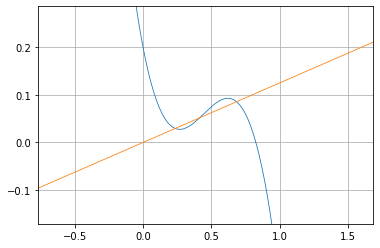

In [79]:
fhn = FHNModel()

fhn.params['x_ext'] = np.array([0.2])
fhn.params['y_ext'] = np.array([0.])
fhn.params.epsilon = 8.

def x1_nullcline(x_):
    return -fhn.params['alpha']*x_**3 + fhn.params['beta']*x_**2 +fhn.params['gamma']*x_ + fhn.params['x_ext']

def x2_nullcline(x_):
    return (x_ + fhn.params['y_ext']*fhn.params['tau'])/fhn.params['epsilon']

def fp_func(x_):
    return x2_nullcline(x_) - x1_nullcline(x_)

low_lim = -2.
up_lim = 2.
x = np.arange(low_lim,up_lim,0.01)

ic_bistability = [0.2, 0.4, 0.6]

# fixed points for default parameter choice
fixed_points_x = fsolve(fp_func, ic_bistability)
fixed_points = np.zeros([len(fixed_points_x), 2])
for i in range(len(fixed_points_x)):
    fixed_points[i,:] = [fixed_points_x[i], x1_nullcline(fixed_points_x[i])[0]]
print("Fixed points: ", np.around(fixed_points,3))
print("low state x = ", fixed_points[0,0])
print("high state x = ", fixed_points[2,0])

# starting close to the three fixed points, we see that two of them are stable
initial_state = [[0.2, 0.0], [0.4, 0.05], [0.7, 0.1]]
fp = 1 # 0,1,2 for three fixed points initial conditions

plt.plot(x,x1_nullcline(x))
plt.plot(x,x2_nullcline(x))
plt.xlim(fixed_points_x[0]-1, fixed_points_x[-1]+1)
plt.ylim(min(fixed_points[:,1])-0.2, max(fixed_points[:,1])+0.2)
plt.show()

# [0.28675644, 0.14337822]

0.23537865970300748 0.029422332462651968


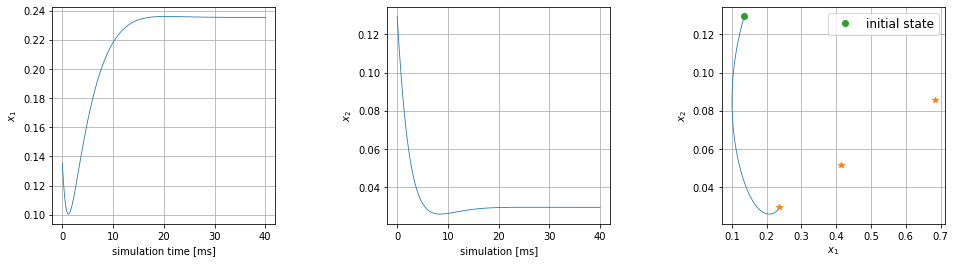

0.23537294503379166


In [83]:
# up state
#fhn.params['xs_init'] = np.array([0.8])
#fhn.params['ys_init'] = np.array([0.1])
# up state
fhn.params['xs_init'] = np.array([fixed_points[0,0]-0.1])
fhn.params['ys_init'] = np.array([fixed_points[0,1]+0.1])
print(fixed_points[0,0], fixed_points[0,1])

fhn.params['duration'] = 40.

fhn.run()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=None)

ax[0].plot(fhn.t, fhn.x[0,:])
ax[0].set(xlabel='simulation time [ms]', ylabel='$x_1$')

ax[1].plot(fhn.t, fhn.y[0,:])
ax[1].set(xlabel='simulation [ms]', ylabel='$x_2$')

ax[2].plot(fhn.x[0,:], fhn.y[0,:])
ax[2].plot(fixed_points[:,0], fixed_points[:,1], '*')
ax[2].plot(fhn.x[0,0], fhn.y[0,0], 'o', label="initial state")
ax[2].legend()
ax[2].set(xlabel='$x_1$', ylabel='$x_2$')

plt.show()

print(fhn.x[0,-1])
# 0.23537865970300748

In [88]:
I_p= 1. #penalize precision
I_e= 1. #penalize control energy
I_s= 0. #enforce sparsity

cost.setParams(I_p, I_e, I_s)
target = fhn.getZeroTarget()
target[:,:,:] = -1.
target[:,0,:] = fixed_points[2,0]

control0 = fhn.getZeroControl()
state = fhn.getZeroState()

set cost params


RUN  0 , total integrated cost:  5.413900776210102
RUN  1 , total integrated cost:  0.017384825837591714
RUN  2 , total integrated cost:  0.015758599263654215
RUN  3 , total integrated cost:  0.01565217324303579
Improved over  3  iterations by  100  percent.
cost_int:  [5.41390078 0.01738483 0.0157586  0.01565217]
runtime:  [11.9104266 24.4142061 37.4878212 37.4899329]


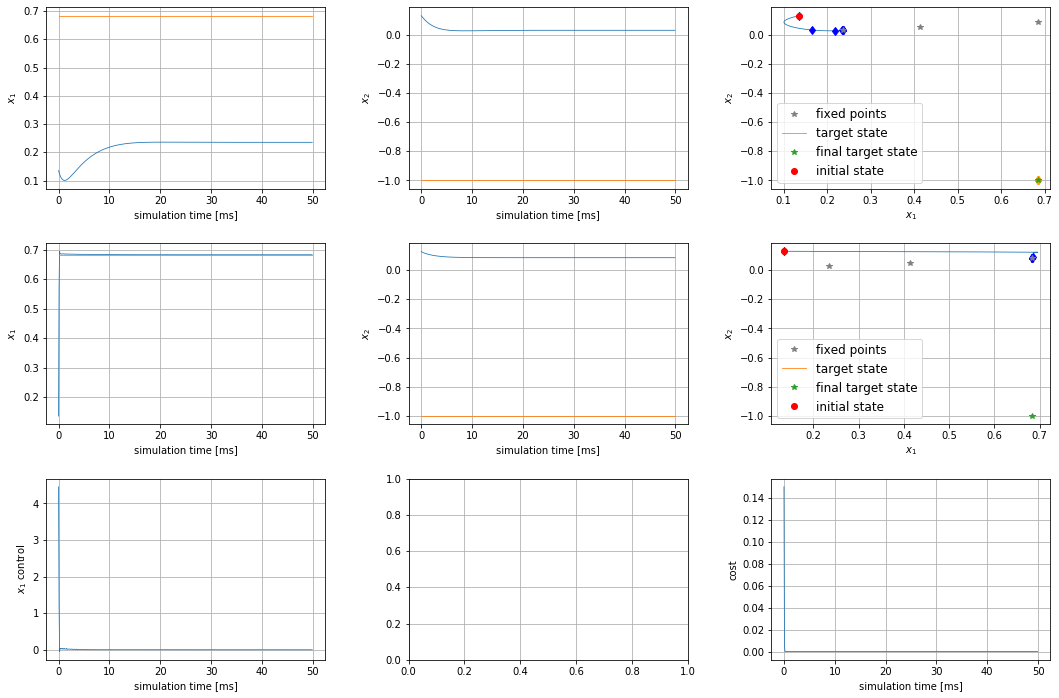

In [24]:
tolerance = 1e-6
stepSize = 0.1
incl_steps = 1000
max_iteration = 3

bestControl, bestState, cost_int, runtime = fhn.A2(control0, target, max_iteration, tolerance, incl_steps)

fhn.run(control = bestControl)

print("cost_int: ", cost_int)
print("runtime: ", runtime)
state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

plot_control(target, bestControl, fhn.cost(state, target, bestControl))

phi =  [-0.3836 -0.3433 -0.3024 -0.2609 -0.2188 -0.1761 -0.1329 -0.0891 -0.0448
  0.    ]
RUN  0 , total integrated cost =  4.4190730493992465
 max iteration reached, step size =  1.8665272370064378e-298
Control only changes marginally.
improved over  96  iterations by  96  percent.
cost:  0.18714213673202038
time:  0.9355813000001945


'\n0.28185966681483937\n '

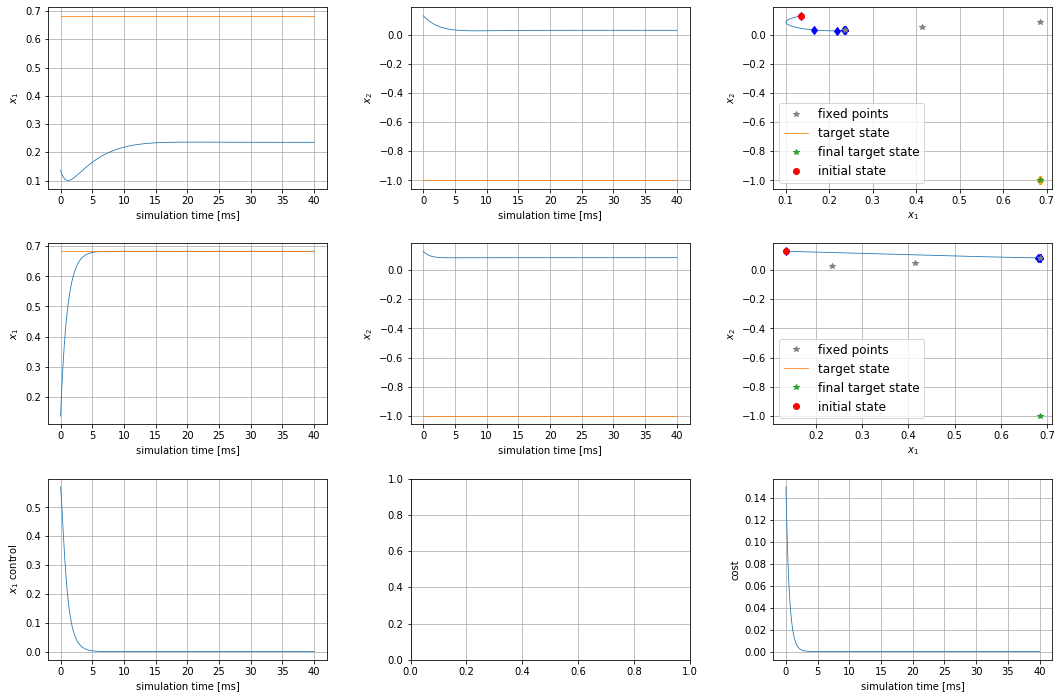

In [94]:
c_mat = np.array([[0.]])
c_scheme = np.zeros((len(fhn.output_vars), len(fhn.output_vars) ))
c_scheme[0,0] = 1.

u_mat = np.identity(fhn.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

fhn.run()

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

#print("initial state = ", state[0,0,:])

optC, opt_state, cost_array, time = fhn.A1(state, target, control0, c_scheme, u_mat, u_scheme, max_iteration_ = 400,
                                    tolerance_ = 1.e-16, startStep_ = 1000., test_step_ = 1e-8, cntrl_max_ = 20.,
                                    CGVar = None)
#print("final state = ", opt_state)
#print("final control = ", optC)
print("cost: ", cost_array[-1])
print("time: ", time[-1])
plot_control(target, optC, fhn.cost(opt_state, target, fhn.getZeroControl()))
#[-0.38636 -0.34572 -0.30449 -0.26265 -0.22024 -0.17727 -0.13374 -0.08967  -0.04509  0.     ]

"""
0.28185966681483937
 """

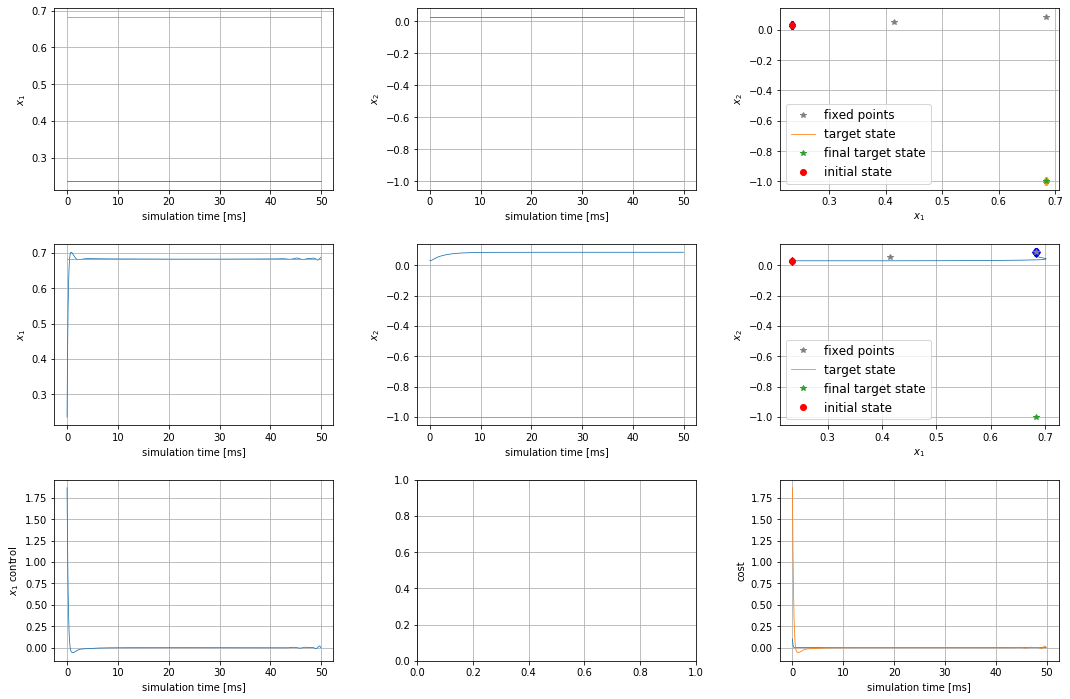

In [7]:
plot_control(target, optC, fhn.cost(opt_state, target, fhn.getZeroControl()))


plt.plot(fhn.t, optC[0,0,:])
plt.show()

In [6]:
# plot uncontrolled dynamics, controlled dynamics
def plot_control(target_, control_, cost_):
    
    # no control
    fhn.run()

    fig, ax = plt.subplots(3, 3, figsize=(18, 12))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)

    ax[0,0].plot(fhn.t, fhn.x[0,:])
    ax[0,0].plot(fhn.t, target_[0,0,:], label="target state")
    ax[0,0].set(xlabel='simulation time [ms]', ylabel='$x_1$')
    ax[0,1].plot(fhn.t, fhn.y[0,:])
    ax[0,1].plot(fhn.t, target_[0,1,:], label="target state")
    ax[0,1].set(xlabel='simulation time [ms]', ylabel='$x_2$')
    ax[0,2].plot(fhn.x[0,:], fhn.y[0,:])
    for i in range(0, int(round(fhn.params['duration']/fhn.params['dt'],1)+1), 50):
        ax[0,2].plot(fhn.x[0,i], fhn.y[0,i], c="blue", marker="d")
    ax[0,2].plot(fixed_points[:,0], fixed_points[:,1], '*', c='grey', label='fixed points')
    ax[0,2].plot(target_[0,0,:], target_[0,1,:], label="target state")
    for i in range(0, int(round(fhn.params['duration']/fhn.params['dt'],1)+1), 50):
        ax[0,2].plot(target_[0,0,i], target_[0,1,i], c="orange", marker="d")
    ax[0,2].plot(target_[0,0,-1], target_[0,1,-1], '*', linewidth = 1, label="final target state")
    ax[0,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', c='red', label="initial state")
    ax[0,2].legend()
    ax[0,2].set(xlabel='$x_1$', ylabel='$x_2$')

    fhn.run(control=control_)

    ax[1,0].plot(fhn.t, fhn.x[0,:], label="$x_1$")
    ax[1,0].plot(fhn.t, target_[0,0,:], label="target state")
    ax[1,0].set(xlabel='simulation time [ms]', ylabel='$x_1$')
    ax[1,1].plot(fhn.t, fhn.y[0,:], label="$x_2$")
    ax[1,1].plot(fhn.t, target_[0,1,:], label="target state")
    ax[1,1].set(xlabel='simulation time [ms]', ylabel='$x_2$')
    ax[1,2].plot(fhn.x[0,:], fhn.y[0,:])
    for i in range(0, int(round(fhn.params['duration']/fhn.params['dt'],1)+1), 50):
        ax[1,2].plot(fhn.x[0,i], fhn.y[0,i], c="blue", marker="d")
    ax[1,2].plot(fixed_points[:,0], fixed_points[:,1], '*', c='grey', label='fixed points')
    ax[1,2].plot(target_[0,0,:], target_[0,1,:], label="target state")
    ax[1,2].plot(target_[0,0,-1], target_[0,1,-1], '*', linewidth = 1, label="final target state")
    ax[1,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', c='red', label="initial state")
    ax[1,2].legend()
    ax[1,2].set(xlabel='$x_1$', ylabel='$x_2$')
    
    ax[2,0].plot(fhn.t, control_[0,0,:])
    ax[2,0].set(xlabel='simulation time [ms]', ylabel='$x_1$ control')
    #ax[2,0].set_ylim(-0.1, 0.1)
    #ax[2,1].plot(fhn.t, control_[0,1,:])
    #ax[2,1].set(xlabel='simulation time [ms]', ylabel='$x_2$ control')
    ax[2,2].plot(fhn.t, cost_)
    ax[2,2].set(xlabel='simulation time [ms]', ylabel='cost')
    
    #plt.savefig('control.png')

In [156]:
x = 0.23537866
print(-9.*x**2 + 8.*x - 1.5)

-0.11559874225056044
